In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
np.random.seed(42)
n_samples = 200


In [ ]:
data = pd.DataFrame({
    'SquareFeet': np.random.randint(800, 3500, size=n_samples),
    'Bedrooms': np.random.randint(1, 5, size=n_samples),
    'Bathrooms': np.random.randint(1, 4, size=n_samples),
    'Neighborhood': np.random.choice(['Downtown', 'Suburbs', 'Rural'], size=n_samples),
    'AgeOfHouse': np.random.randint(0, 50, size=n_samples)
})

In [ ]:

# Generate target price with some noise to make model fitting realistic
data['Price'] = (
    data['SquareFeet'] * 150 +
    data['Bedrooms'] * 25000 +
    data['Bathrooms'] * 15000 -
    data['AgeOfHouse'] * 1200 +
    np.random.normal(0, 20000, size=n_samples)
)

In [ ]:
# Introduce a few missing values intentionally to demonstrate preprocessing
data.loc[data.sample(frac=0.05).index, 'SquareFeet'] = np.nan

print("--- Initial Dataset Sample ---")
print(data.head())

--- Initial Dataset Sample ---
   SquareFeet  Bedrooms  Bathrooms Neighborhood  AgeOfHouse          Price
0      1660.0         4          3      Suburbs          12  410062.481545
1      2094.0         3          2     Downtown          32  391478.200874
2      1930.0         3          2        Rural          33  334155.076913
3      1895.0         4          3        Rural          40  377443.226438
4      2438.0         3          2      Suburbs          34  412387.634932


In [ ]:
X = data.drop(columns=['Price'])
y = data['Price']


In [ ]:
# Group features by data type for structured pipeline preprocessing
num_features = ['SquareFeet', 'Bedrooms', 'Bathrooms', 'AgeOfHouse']
cat_features = ['Neighborhood']


In [ ]:
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])



In [ ]:
cat_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42)
}

In [ ]:
print("\n--- Model Evaluation Performance ---")
for name, model in models.items():
    # Build unified pipeline containing preprocessing logic + predictive model
    clf = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])



--- Model Evaluation Performance ---


In [ ]:
  clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SquareFeet', 'Bedrooms',
                                                   'Bathrooms', 'AgeOfHouse']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Neighborhood'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [ ]:
predictions = clf.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"{name}:")
print(f"  Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"  R² Score (Accuracy Metric): {r2:.4f}\n")

Random Forest Regressor:
  Mean Absolute Error (MAE): $22,422.30
  R² Score (Accuracy Metric): 0.9353



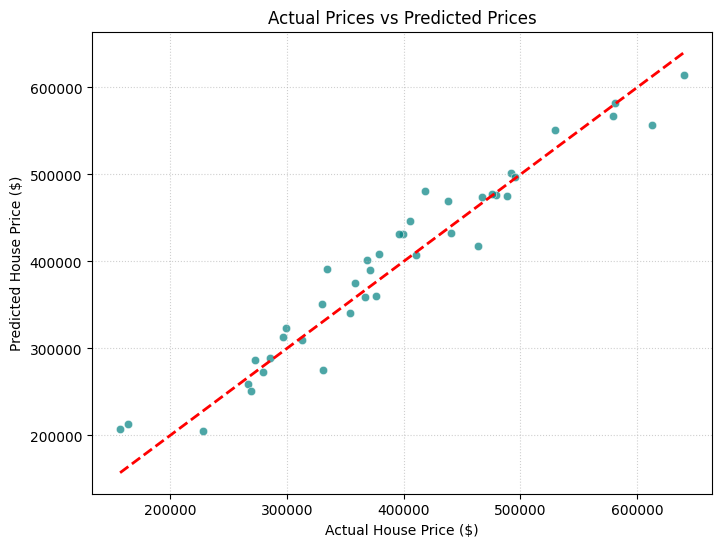

In [ ]:
final_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('model', RandomForestRegressor(n_estimators=100, random_state=42))])
final_pipeline.fit(X_train, y_train)
test_preds = final_pipeline.predict(X_test)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=test_preds, color='teal', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
plt.title('Actual Prices vs Predicted Prices')
plt.xlabel('Actual House Price ($)')
plt.ylabel('Predicted House Price ($)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()